In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../../data/pivot_data.parquet")

In [3]:
columns = [
    "SSA 4 Schacht ec (1) 120cm mS/cm",
    "SSA 4 Schacht ec (1) 30cm mS/cm",
    "SSA 4 Schacht ec (1) 75cm mS/cm",
    "SSA 4 Schacht ec (2) 120cm mS/cm",
    "SSA 4 Schacht ec (2) 30cm mS/cm",
    "SSA 4 Schacht ec (2) 75cm mS/cm",
    "SSA 4 Schacht UMP (1) 30cm %",
    "SSA 4 Schacht UMP (1) 75cm %"
]


In [4]:
# Select all columns listed in the 'columns' variable to create a new dataset
new_dataset = df[columns].copy()
new_dataset.head()

MeasurementName,SSA 4 Schacht ec (1) 120cm mS/cm,SSA 4 Schacht ec (1) 30cm mS/cm,SSA 4 Schacht ec (1) 75cm mS/cm,SSA 4 Schacht ec (2) 120cm mS/cm,SSA 4 Schacht ec (2) 30cm mS/cm,SSA 4 Schacht ec (2) 75cm mS/cm,SSA 4 Schacht UMP (1) 30cm %,SSA 4 Schacht UMP (1) 75cm %
MeasureDate,,,,,,,,
2013-07-01 00:00:00,0.14,0.12,0.1,0.13,0.23,0.09,30.180000,31.000000
2013-07-01 00:14:00,0.14,0.11,0.1,0.13,0.23,0.09,30.190001,31.010000
2013-07-01 00:30:00,0.14,0.12,0.1,0.13,0.23,0.09,30.190001,30.969999
2013-07-01 00:45:00,0.14,0.12,0.1,0.13,0.23,0.09,30.190001,30.990000
2013-07-01 00:59:00,0.14,0.11,0.1,0.13,0.23,0.09,30.180000,30.980000


['SSA 4 Schacht ec (1) 120cm mS/cm', 'SSA 4 Schacht ec (1) 30cm mS/cm', 'SSA 4 Schacht ec (1) 75cm mS/cm', 'SSA 4 Schacht ec (2) 120cm mS/cm', 'SSA 4 Schacht ec (2) 30cm mS/cm', 'SSA 4 Schacht ec (2) 75cm mS/cm', 'SSA 4 Schacht UMP (1) 30cm %', 'SSA 4 Schacht UMP (1) 75cm %']


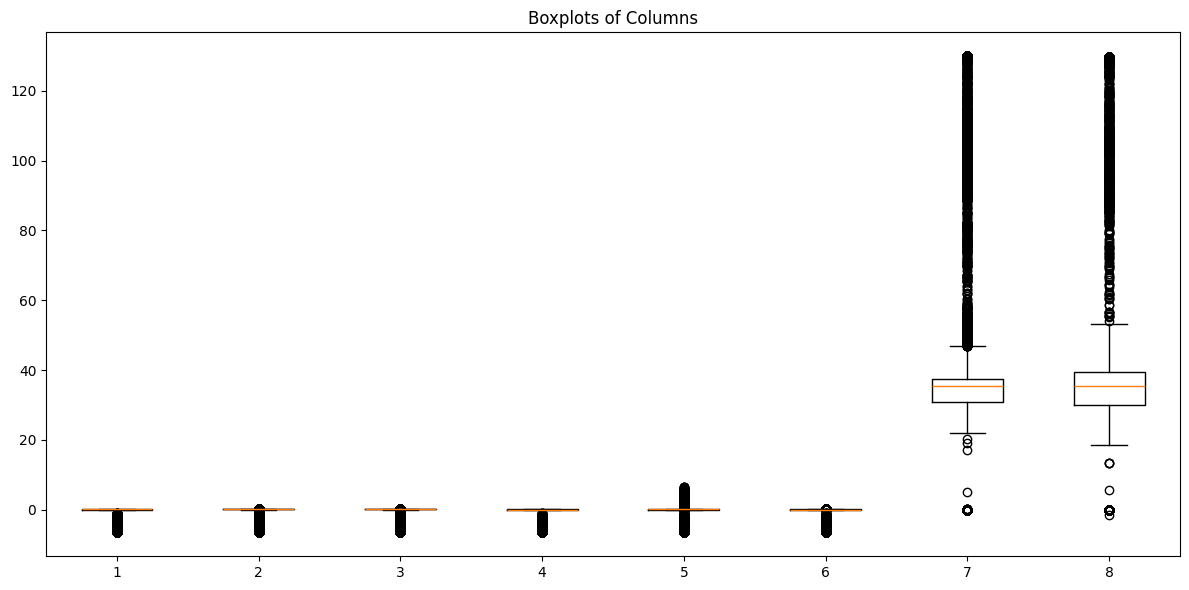

In [ ]:
import matplotlib.pyplot as plt

cols = new_dataset.columns.tolist()
print(cols)
plt.figure(figsize=(12, 6))
plt.boxplot(new_dataset[cols].dropna())
plt.title("Boxplots of Columns")
plt.tight_layout()
plt.savefig("graphs/boxplot_outliers.png")
plt.show()

In [6]:
new_dataset.describe()

MeasurementName,SSA 4 Schacht ec (1) 120cm mS/cm,SSA 4 Schacht ec (1) 30cm mS/cm,SSA 4 Schacht ec (1) 75cm mS/cm,SSA 4 Schacht ec (2) 120cm mS/cm,SSA 4 Schacht ec (2) 30cm mS/cm,SSA 4 Schacht ec (2) 75cm mS/cm,SSA 4 Schacht UMP (1) 30cm %,SSA 4 Schacht UMP (1) 75cm %
count,346200.000000,346200.000000,346200.000000,346200.000000,346200.000000,346200.000000,346200.000000,346200.000000
mean,0.065721,0.070193,0.069241,0.061278,0.063587,0.018959,34.755251,34.032075
std,0.418870,0.414915,0.415629,0.420548,0.425294,0.413957,8.371570,9.467609
min,-6.490000,-6.500000,-6.470000,-6.480000,-6.470000,-6.480000,-0.050000,-1.610000
25%,0.060000,0.080000,0.080000,0.040000,0.060000,0.020000,30.980000,30.020000
50%,0.110000,0.100000,0.100000,0.070000,0.090000,0.030000,35.580002,35.400002
75%,0.140000,0.120000,0.110000,0.140000,0.120000,0.080000,37.349998,39.389999
max,0.240000,0.260000,0.240000,0.260000,6.570000,0.190000,129.910004,129.539993


In [7]:
sacht_30cm = new_dataset["SSA 4 Schacht ec (1) 30cm mS/cm"]
sacht_75cm = new_dataset["SSA 4 Schacht ec (1) 75cm mS/cm"]

In [8]:
sacht_30cm.describe()

count    346200.000000
mean          0.070193
std           0.414915
min          -6.500000
25%           0.080000
50%           0.100000
75%           0.120000
max           0.260000
Name: SSA 4 Schacht ec (1) 30cm mS/cm, dtype: float64

In [9]:
sacht_30cm.isna().sum()

np.int64(25682)

Text(0.5, 1.0, 'SSA 4 Schacht ec (1) 30cm mS/cm')

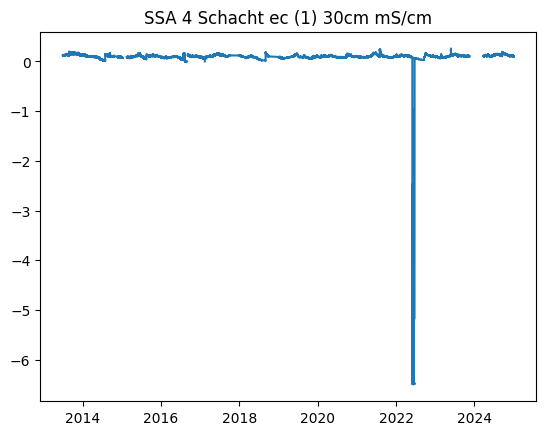

In [10]:
import matplotlib.pyplot as plt
date = new_dataset.index

plt.plot(date, sacht_30cm,)
plt.title("SSA 4 Schacht ec (1) 30cm mS/cm")

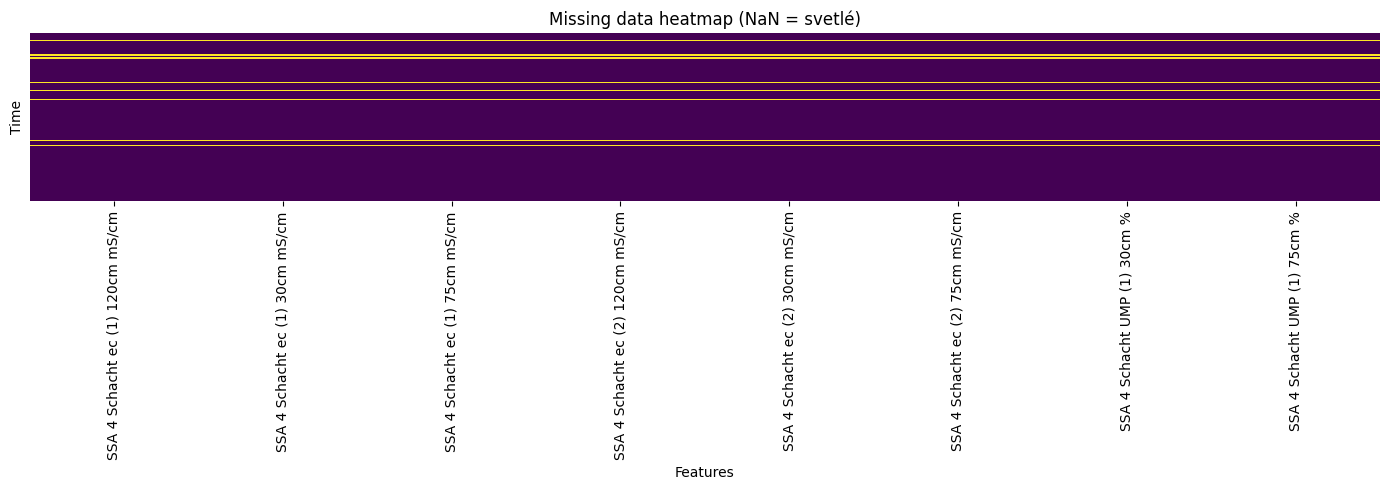

In [11]:
import seaborn as sns


plt.figure(figsize=(14, 5))
sns.heatmap(
    new_dataset.isna(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"   # môžeš dať aj "mako", "rocket", "crest"
)
plt.title("Missing data heatmap (NaN = svetlé)")
plt.xlabel("Features")
plt.ylabel("Time")
plt.tight_layout()
plt.show()

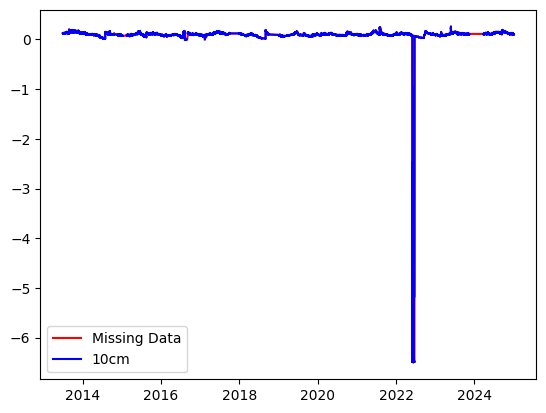

In [12]:
import matplotlib.pyplot as plt
date = new_dataset.index

# Interpolate missing values to visualize the gaps
sacht_30cm_filled = sacht_30cm.interpolate()

plt.plot(date, sacht_30cm_filled, color='red', linestyle='-', label="Missing Data")
plt.plot(date, sacht_30cm, color='blue', label="10cm")
plt.legend()
plt.savefig("graphs/sacht_30cm_missing_data.png")

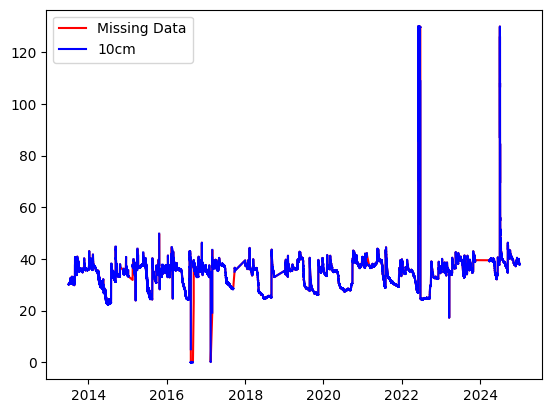

In [13]:
SSA_4_Schacht_UMP = new_dataset["SSA 4 Schacht UMP (1) 30cm %"]
date = new_dataset.index

# Interpolate missing values to visualize the gaps
SSA_4_Schacht_UMP_filled = SSA_4_Schacht_UMP.interpolate()

plt.plot(date, SSA_4_Schacht_UMP_filled, color='red', linestyle='-', label="Missing Data")
plt.plot(date, SSA_4_Schacht_UMP, color='blue', label="10cm")
plt.legend()
plt.savefig("graphs/SSA 4Schacht UMP (1) 30cm %.png")
